# Cattle Collar Switch-or-Stay AI Pipeline

This Colab-ready notebook implements the cattle collar app architecture from the project brief and flow diagram. It includes transparent switch/stay arithmetic, a connectivity hard gate, ML estimation of fuzzy fence-cost inputs, a reinforcement-learning-style simulator, sensitivity analysis, Monte Carlo uncertainty, and a statistics/alarm layer.

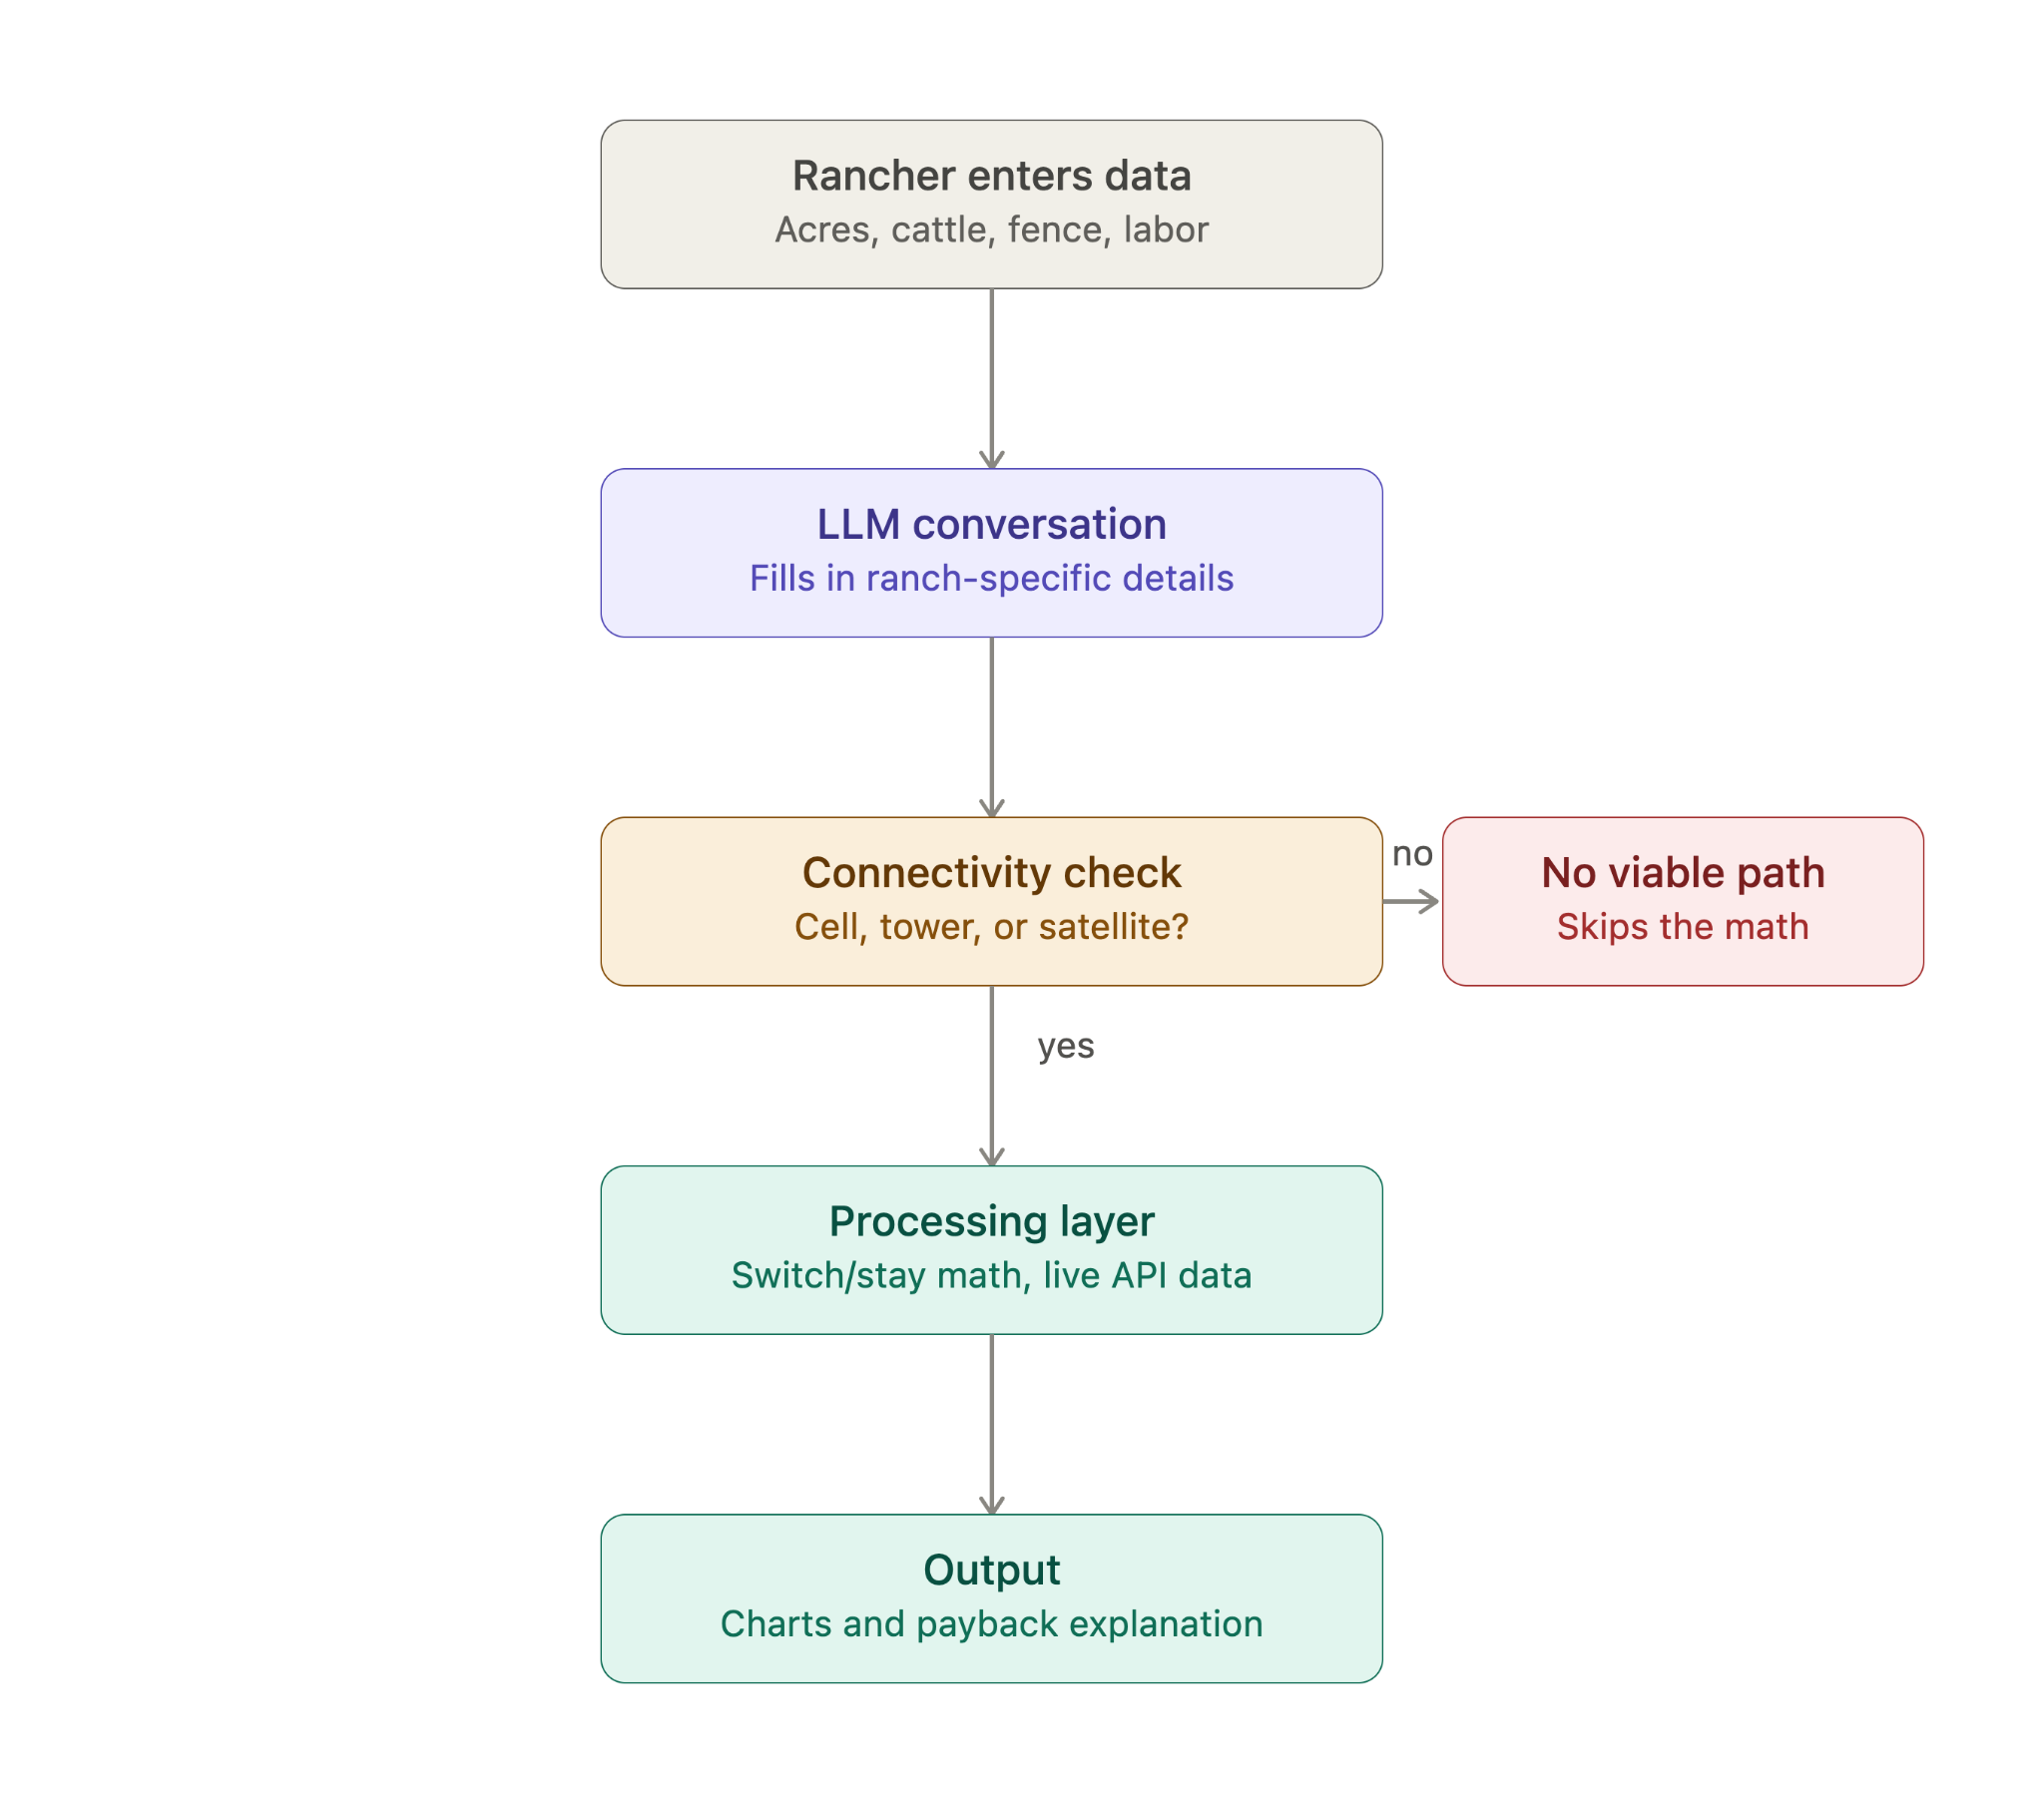

**Important MVP rule:** if there is no viable cell, tower/base-station, or satellite path, the notebook should skip the ROI math and return `No viable path`.


## 1. Setup

In Google Colab, uncomment the install line if any dependency is missing. The notebook uses standard scientific Python packages and Plotly for visualizations.

In [ ]:
# Uncomment in Colab if needed:
# !pip -q install pandas numpy scikit-learn plotly requests

import math
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown


## 2. Core functions

This cell contains the reusable functions used by both the notebook and the Streamlit app.

In [ ]:
from __future__ import annotations

import json
import math
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# -----------------------------------------------------------------------------
# Core assumptions
# -----------------------------------------------------------------------------
# These are editable starter assumptions for an MVP. They are intentionally not
# hard-coded as vendor quotes. In production, update them from approved vendor
# quotes, public data, or user-entered values.

DEFAULT_SYSTEM_PRESETS: Dict[str, Dict[str, float | str]] = {
    "Cell-based collar system": {
        "system_type": "cell",
        "collar_hardware_cost": 275.0,
        "subscription_per_head_month": 8.0,
        "base_station_cost": 0.0,
        "tower_maintenance_annual": 0.0,
        "install_cost": 2500.0,
    },
    "Tower/base-station collar system": {
        "system_type": "tower",
        "collar_hardware_cost": 300.0,
        "subscription_per_head_month": 6.0,
        "base_station_cost": 15000.0,
        "tower_maintenance_annual": 750.0,
        "install_cost": 5000.0,
    },
    "Satellite collar system": {
        "system_type": "satellite",
        "collar_hardware_cost": 325.0,
        "subscription_per_head_month": 12.0,
        "base_station_cost": 0.0,
        "tower_maintenance_annual": 0.0,
        "install_cost": 3500.0,
    },
}

COST_PARAMETER_TABLE = pd.DataFrame(
    [
        {
            "parameter": "Collar hardware per head",
            "captures": "Up-front collar cost times herd size",
            "source_basis": "Vendor pricing or ranch quote",
        },
        {
            "parameter": "Subscription or service",
            "captures": "Recurring per-collar or per-ranch service fee",
            "source_basis": "Vendor pricing or ranch quote",
        },
        {
            "parameter": "Base station or tower",
            "captures": "On-ranch infrastructure required for some systems",
            "source_basis": "Vendor specs plus install benchmark",
        },
        {
            "parameter": "Existing fence per mile",
            "captures": "Analog fence build, repair, and material burden",
            "source_basis": "NRCS practice cost, extension budgets, or ranch input",
        },
        {
            "parameter": "Fence repair labor",
            "captures": "Recurring hours fixing broken fence",
            "source_basis": "Extension benchmark plus ranch input",
        },
        {
            "parameter": "Cattle-moving labor",
            "captures": "Recurring hours moving cattle among pastures",
            "source_basis": "Extension benchmark plus ranch input",
        },
        {
            "parameter": "Cost-share offset",
            "captures": "Government or grant payment lowering net switch cost",
            "source_basis": "NRCS EQIP or local program rules",
        },
    ]
)

FEATURE_COLUMNS = [
    "acres",
    "head_cattle",
    "fence_miles",
    "repair_hours_per_month",
    "moving_hours_per_month",
    "risk_tolerance",
    "cost_sensitivity",
    "tech_comfort",
    "conservation_priority",
    "owned_share",
]


def normalize_system_type(system_type: str | None) -> str:
    """Normalize a system label to cell, tower, satellite, stay, or auto."""
    if system_type is None:
        return "auto"
    s = str(system_type).strip().lower()
    if not s or s == "auto" or "auto" in s:
        return "auto"
    if "stay" in s or "analog" in s or "physical" in s:
        return "stay"
    if "cell" in s:
        return "cell"
    if "tower" in s or "base" in s:
        return "tower"
    if "sat" in s:
        return "satellite"
    return s


def get_preset(system_type: str | None) -> Dict[str, Any]:
    """Return a cost preset for cell, tower, or satellite systems."""
    normalized = normalize_system_type(system_type)
    if normalized == "auto":
        normalized = "cell"
    for label, preset in DEFAULT_SYSTEM_PRESETS.items():
        if normalized == normalize_system_type(label) or normalized == preset["system_type"]:
            return dict(preset)
    raise ValueError(f"Unknown system type: {system_type}")


def example_ranch_inputs() -> Dict[str, Any]:
    """Return a complete sample ranch profile used by the notebook and app."""
    return {
        "location_name": "Example Ranch",
        "latitude": 38.5,
        "longitude": -106.0,
        "owned_or_leased": "Owned",
        "acres": 5000.0,
        "head_cattle": 600,
        "fence_miles": 42.0,
        "repair_hours_per_month": 20.0,
        "moving_hours_per_month": 18.0,
        "labor_rate": 28.0,
        "fence_repair_material_per_mile_annual": 250.0,
        "virtual_labor_hours_per_month": 5.0,
        "collar_hardware_cost": 275.0,
        "subscription_per_head_month": 8.0,
        "ranch_platform_fee_annual": 0.0,
        "base_station_cost": 0.0,
        "install_cost": 2500.0,
        "training_hours": 24.0,
        "collar_replacement_rate": 0.08,
        "tower_maintenance_annual": 0.0,
        "cost_share_rate": 0.35,
        "fixed_cost_share": 0.0,
        "discount_rate": 0.08,
        "horizon_years": 7,
        "target_payback_years": 4.0,
        "system_type": "cell",
        "optional_conservation_value_annual": 0.0,
        "optional_grazing_gain_annual": 0.0,
        "capital_available": 250000.0,
    }


def check_connectivity(
    cell_available: bool,
    tower_possible: bool,
    satellite_available: bool,
    preferred_path: str | None = "auto",
) -> Dict[str, Any]:
    """Connectivity hard gate.

    If no cell, tower, or satellite path can work, the model should not run the
    switch/stay math. If a preferred path is not viable but another path is, the
    function still returns viable=True and provides a recommended fallback.
    """
    viable_paths: List[str] = []
    if cell_available:
        viable_paths.append("cell")
    if tower_possible:
        viable_paths.append("tower")
    if satellite_available:
        viable_paths.append("satellite")

    preferred = normalize_system_type(preferred_path)
    if not viable_paths:
        return {
            "viable": False,
            "viable_paths": [],
            "recommended_path": None,
            "preferred_path": preferred,
            "preferred_viable": False,
            "message": "No viable cell, tower, or satellite path. Skip the math and report no viable path.",
        }

    priority = ["cell", "tower", "satellite"]
    recommended = next(path for path in priority if path in viable_paths)
    preferred_viable = preferred in viable_paths if preferred not in {"auto", "stay"} else True
    if preferred not in {"auto", "stay"} and preferred_viable:
        recommended = preferred
    elif preferred not in {"auto", "stay"} and not preferred_viable:
        # Keep the calculation alive but call out that the preferred brand/path fails.
        recommended = next(path for path in priority if path in viable_paths)

    message = f"Viable path(s): {', '.join(viable_paths)}. Recommended path: {recommended}."
    if preferred not in {"auto", "stay"} and not preferred_viable:
        message += f" Preferred path '{preferred}' is not viable on this land."

    return {
        "viable": True,
        "viable_paths": viable_paths,
        "recommended_path": recommended,
        "preferred_path": preferred,
        "preferred_viable": preferred_viable,
        "message": message,
    }


def apply_system_preset(inputs: Dict[str, Any], system_type: str) -> Dict[str, Any]:
    """Return a copy of inputs updated with a system preset."""
    updated = dict(inputs)
    preset = get_preset(system_type)
    updated.update(preset)
    return updated


def _num(inputs: Dict[str, Any], key: str, default: float = 0.0) -> float:
    value = inputs.get(key, default)
    if value is None or value == "":
        return float(default)
    try:
        return float(value)
    except Exception:
        return float(default)


def compute_switch_stay_economics(inputs: Dict[str, Any]) -> Dict[str, Any]:
    """Compute transparent switch/stay economics.

    Headline recommendation intentionally excludes optional soft benefits.
    Optional conservation and grazing benefits are reported separately.
    """
    head = max(0.0, _num(inputs, "head_cattle"))
    fence_miles = max(0.0, _num(inputs, "fence_miles"))
    labor_rate = max(0.0, _num(inputs, "labor_rate"))
    repair_hours_annual = max(0.0, _num(inputs, "repair_hours_per_month")) * 12.0
    moving_hours_annual = max(0.0, _num(inputs, "moving_hours_per_month")) * 12.0
    virtual_labor_hours_annual = max(0.0, _num(inputs, "virtual_labor_hours_per_month")) * 12.0

    fence_material_per_mile = max(0.0, _num(inputs, "fence_repair_material_per_mile_annual"))
    analog_repair_labor = repair_hours_annual * labor_rate
    analog_moving_labor = moving_hours_annual * labor_rate
    analog_material = fence_miles * fence_material_per_mile
    analog_annual_total = analog_repair_labor + analog_moving_labor + analog_material

    collar_cost = max(0.0, _num(inputs, "collar_hardware_cost"))
    subscription_monthly = max(0.0, _num(inputs, "subscription_per_head_month"))
    platform_fee = max(0.0, _num(inputs, "ranch_platform_fee_annual"))
    base_station_cost = max(0.0, _num(inputs, "base_station_cost"))
    install_cost = max(0.0, _num(inputs, "install_cost"))
    training_hours = max(0.0, _num(inputs, "training_hours"))
    replacement_rate = min(max(0.0, _num(inputs, "collar_replacement_rate")), 1.0)
    tower_maintenance = max(0.0, _num(inputs, "tower_maintenance_annual"))

    hardware_cost = head * collar_cost
    training_cost = training_hours * labor_rate
    gross_upfront = hardware_cost + base_station_cost + install_cost + training_cost

    cost_share_rate = min(max(0.0, _num(inputs, "cost_share_rate")), 0.95)
    fixed_cost_share = max(0.0, _num(inputs, "fixed_cost_share"))
    cost_share_offset = min(gross_upfront, gross_upfront * cost_share_rate + fixed_cost_share)
    net_upfront = max(0.0, gross_upfront - cost_share_offset)

    virtual_subscription = head * subscription_monthly * 12.0 + platform_fee
    virtual_labor = virtual_labor_hours_annual * labor_rate
    collar_replacement = head * collar_cost * replacement_rate
    virtual_annual_total = virtual_subscription + virtual_labor + collar_replacement + tower_maintenance

    annual_savings = analog_annual_total - virtual_annual_total
    discount_rate = max(-0.95, _num(inputs, "discount_rate", 0.08))
    horizon = int(max(1, round(_num(inputs, "horizon_years", 7))))
    target_payback = max(0.1, _num(inputs, "target_payback_years", 4.0))

    if annual_savings > 0:
        payback_years = net_upfront / annual_savings if annual_savings else math.inf
    else:
        payback_years = math.inf

    npv = -net_upfront + sum(annual_savings / ((1.0 + discount_rate) ** year) for year in range(1, horizon + 1))
    total_net_benefit = annual_savings * horizon - net_upfront
    roi_multiple = total_net_benefit / net_upfront if net_upfront > 0 else math.inf

    optional_annual_upside = max(0.0, _num(inputs, "optional_conservation_value_annual")) + max(
        0.0, _num(inputs, "optional_grazing_gain_annual")
    )
    npv_with_optional = -net_upfront + sum(
        (annual_savings + optional_annual_upside) / ((1.0 + discount_rate) ** year)
        for year in range(1, horizon + 1)
    )

    if annual_savings <= 0:
        recommendation_short = "stay"
        recommendation = "Stay with physical fencing for now: virtual fencing is more expensive annually under these assumptions."
    elif npv < 0:
        recommendation_short = "stay"
        recommendation = "Stay or negotiate costs: annual savings exist, but discounted value is negative over the selected horizon."
    elif payback_years <= target_payback:
        recommendation_short = "switch"
        recommendation = "Switch: virtual fencing clears the target payback period and has positive discounted value."
    elif payback_years <= horizon:
        recommendation_short = "borderline"
        recommendation = "Borderline: virtual fencing pays back inside the analysis horizon, but slower than the target payback."
    else:
        recommendation_short = "stay"
        recommendation = "Stay for now: payback is longer than the analysis horizon."

    return {
        "system_type": normalize_system_type(inputs.get("system_type", "auto")),
        "analog_repair_labor": analog_repair_labor,
        "analog_moving_labor": analog_moving_labor,
        "analog_material": analog_material,
        "analog_annual_total": analog_annual_total,
        "hardware_cost": hardware_cost,
        "base_station_cost": base_station_cost,
        "install_cost": install_cost,
        "training_cost": training_cost,
        "gross_upfront": gross_upfront,
        "cost_share_offset": cost_share_offset,
        "net_upfront": net_upfront,
        "virtual_subscription": virtual_subscription,
        "virtual_labor": virtual_labor,
        "collar_replacement": collar_replacement,
        "tower_maintenance": tower_maintenance,
        "virtual_annual_total": virtual_annual_total,
        "annual_savings": annual_savings,
        "payback_years": payback_years,
        "discount_rate": discount_rate,
        "horizon_years": horizon,
        "target_payback_years": target_payback,
        "npv": npv,
        "total_net_benefit": total_net_benefit,
        "roi_multiple": roi_multiple,
        "optional_annual_upside": optional_annual_upside,
        "npv_with_optional": npv_with_optional,
        "recommendation_short": recommendation_short,
        "recommendation": recommendation,
    }


def build_cash_flow_table(economics: Dict[str, Any]) -> pd.DataFrame:
    """Build annual and cumulative cash-flow rows for plotting."""
    horizon = int(economics["horizon_years"])
    annual_savings = float(economics["annual_savings"])
    net_upfront = float(economics["net_upfront"])
    discount_rate = float(economics["discount_rate"])
    rows = []
    cumulative = -net_upfront
    cumulative_discounted = -net_upfront
    rows.append(
        {
            "year": 0,
            "annual_cash_flow": -net_upfront,
            "discounted_cash_flow": -net_upfront,
            "cumulative_undiscounted": cumulative,
            "cumulative_discounted": cumulative_discounted,
        }
    )
    for year in range(1, horizon + 1):
        discounted = annual_savings / ((1.0 + discount_rate) ** year)
        cumulative += annual_savings
        cumulative_discounted += discounted
        rows.append(
            {
                "year": year,
                "annual_cash_flow": annual_savings,
                "discounted_cash_flow": discounted,
                "cumulative_undiscounted": cumulative,
                "cumulative_discounted": cumulative_discounted,
            }
        )
    return pd.DataFrame(rows)


def make_payback_explanation(inputs: Dict[str, Any], economics: Dict[str, Any]) -> str:
    """Plain-language explanation for the rancher."""
    if not math.isfinite(float(economics["payback_years"])):
        return (
            "The switch does not pay back under the current assumptions because the annual virtual-fencing "
            "cost is greater than or equal to the analog fencing burden. The fastest levers to test are "
            "subscription cost, collar hardware cost, labor hours spent moving cattle, and cost-share offset."
        )
    return (
        f"The ranch spends about ${economics['analog_annual_total']:,.0f} per year on analog fence labor, "
        f"cattle-moving labor, and repair material. The virtual system would cost about "
        f"${economics['virtual_annual_total']:,.0f} per year after installation, creating about "
        f"${economics['annual_savings']:,.0f} in annual savings. Net switch cost after cost share is "
        f"${economics['net_upfront']:,.0f}, so the payback period is about "
        f"{economics['payback_years']:.1f} years. Optional conservation or grazing upside is tracked "
        "separately and is not included in the headline recommendation."
    )


def build_sensitivity_table(inputs: Dict[str, Any], pct: float = 0.20) -> pd.DataFrame:
    """Vary one input at a time and show what changes the answer most."""
    base = compute_switch_stay_economics(inputs)
    base_npv = float(base["npv"])
    specs = [
        ("Collar hardware", "collar_hardware_cost"),
        ("Subscription", "subscription_per_head_month"),
        ("Labor rate", "labor_rate"),
        ("Fence repair hours", "repair_hours_per_month"),
        ("Cattle-moving hours", "moving_hours_per_month"),
        ("Fence material per mile", "fence_repair_material_per_mile_annual"),
        ("Cost-share rate", "cost_share_rate"),
        ("Base station cost", "base_station_cost"),
    ]
    rows = []
    for label, key in specs:
        original = _num(inputs, key)
        low_inputs = dict(inputs)
        high_inputs = dict(inputs)
        if key == "cost_share_rate":
            low_inputs[key] = max(0.0, original - pct)
            high_inputs[key] = min(0.95, original + pct)
        else:
            low_inputs[key] = max(0.0, original * (1.0 - pct))
            high_inputs[key] = max(0.0, original * (1.0 + pct))
        low = compute_switch_stay_economics(low_inputs)
        high = compute_switch_stay_economics(high_inputs)
        rows.append(
            {
                "parameter": label,
                "base_value": original,
                "low_value": low_inputs[key],
                "high_value": high_inputs[key],
                "base_npv": base_npv,
                "low_npv": low["npv"],
                "high_npv": high["npv"],
                "npv_swing": max(abs(low["npv"] - base_npv), abs(high["npv"] - base_npv)),
                "low_payback": low["payback_years"],
                "high_payback": high["payback_years"],
            }
        )
    return pd.DataFrame(rows).sort_values("npv_swing", ascending=False).reset_index(drop=True)


def monte_carlo_uncertainty(inputs: Dict[str, Any], n: int = 1000, seed: int = 7) -> pd.DataFrame:
    """Simple uncertainty simulation around key assumptions."""
    rng = np.random.default_rng(seed)
    rows = []

    def positive_normal(mean: float, rel_sigma: float) -> float:
        sigma = abs(mean) * rel_sigma if mean else rel_sigma
        return max(0.0, float(rng.normal(mean, sigma)))

    for i in range(n):
        sample = dict(inputs)
        sample["collar_hardware_cost"] = positive_normal(_num(inputs, "collar_hardware_cost"), 0.15)
        sample["subscription_per_head_month"] = positive_normal(_num(inputs, "subscription_per_head_month"), 0.20)
        sample["labor_rate"] = positive_normal(_num(inputs, "labor_rate"), 0.15)
        sample["repair_hours_per_month"] = positive_normal(_num(inputs, "repair_hours_per_month"), 0.25)
        sample["moving_hours_per_month"] = positive_normal(_num(inputs, "moving_hours_per_month"), 0.25)
        sample["fence_repair_material_per_mile_annual"] = positive_normal(
            _num(inputs, "fence_repair_material_per_mile_annual"), 0.25
        )
        sample["cost_share_rate"] = float(np.clip(rng.normal(_num(inputs, "cost_share_rate"), 0.10), 0.0, 0.95))
        econ = compute_switch_stay_economics(sample)
        rows.append(
            {
                "run": i + 1,
                "npv": econ["npv"],
                "payback_years": econ["payback_years"],
                "annual_savings": econ["annual_savings"],
                "recommendation_short": econ["recommendation_short"],
            }
        )
    return pd.DataFrame(rows)


def generate_synthetic_fence_training_data(n: int = 900, seed: int = 42) -> pd.DataFrame:
    """Synthetic data generator for the ML fence-cost estimator.

    Replace this with vetted NRCS/extension/vendor/ranch data in production.
    """
    rng = np.random.default_rng(seed)
    regions = np.array(["Mountain West", "Great Plains", "Southwest", "Pacific", "Southeast"])
    terrains = np.array(["flat", "rolling", "rough", "mountain"])
    region_factor = {
        "Mountain West": 1.20,
        "Great Plains": 0.95,
        "Southwest": 1.05,
        "Pacific": 1.30,
        "Southeast": 0.90,
    }
    terrain_factor = {"flat": 0.80, "rolling": 1.00, "rough": 1.25, "mountain": 1.45}
    rows = []
    for _ in range(n):
        acres = float(np.clip(rng.lognormal(mean=np.log(3500), sigma=0.85), 200, 60000))
        fence_miles = float(np.clip(np.sqrt(acres) / 8.0 + rng.normal(8, 6), 1, 180))
        labor_rate = float(np.clip(rng.normal(28, 8), 12, 65))
        region = str(rng.choice(regions))
        terrain = str(rng.choice(terrains, p=[0.35, 0.35, 0.22, 0.08]))
        base = 165 * region_factor[region] * terrain_factor[terrain]
        scale = 0.0015 * acres / max(fence_miles, 1)
        labor_component = 2.0 * labor_rate * terrain_factor[terrain]
        noise = rng.normal(0, 35)
        target = max(35.0, base + scale + labor_component + noise)
        rows.append(
            {
                "acres": acres,
                "fence_miles": fence_miles,
                "labor_rate": labor_rate,
                "region": region,
                "terrain": terrain,
                "fence_repair_material_per_mile_annual": target,
            }
        )
    return pd.DataFrame(rows)


def train_fence_cost_model(seed: int = 42) -> Tuple[Pipeline, pd.DataFrame, float]:
    """Train an MVP random-forest model to estimate annual fence repair material per mile."""
    train_df = generate_synthetic_fence_training_data(seed=seed)
    x_cols = ["acres", "fence_miles", "labor_rate", "region", "terrain"]
    y_col = "fence_repair_material_per_mile_annual"
    pre = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), ["region", "terrain"]),
            ("num", "passthrough", ["acres", "fence_miles", "labor_rate"]),
        ]
    )
    model = Pipeline(
        steps=[
            ("preprocess", pre),
            ("model", RandomForestRegressor(n_estimators=180, random_state=seed, min_samples_leaf=4)),
        ]
    )
    model.fit(train_df[x_cols], train_df[y_col])
    score = float(model.score(train_df[x_cols], train_df[y_col]))
    return model, train_df, score


def estimate_fence_repair_material(
    model: Pipeline,
    acres: float,
    fence_miles: float,
    labor_rate: float,
    region: str,
    terrain: str,
) -> float:
    """Estimate annual fence repair material cost per mile."""
    row = pd.DataFrame(
        [
            {
                "acres": acres,
                "fence_miles": fence_miles,
                "labor_rate": labor_rate,
                "region": region,
                "terrain": terrain,
            }
        ]
    )
    return float(model.predict(row)[0])


def generate_user_profile_population(n: int = 350, seed: int = 13) -> pd.DataFrame:
    """Create synthetic anonymous rancher profiles for a clustering demo."""
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n):
        acres = float(np.clip(rng.lognormal(np.log(4200), 0.9), 150, 80000))
        head = int(np.clip(acres / rng.normal(8, 3), 30, 6000))
        fence_miles = float(np.clip(np.sqrt(acres) / 7 + rng.normal(6, 6), 1, 220))
        repair = float(np.clip(rng.normal(16, 9), 1, 80))
        moving = float(np.clip(rng.normal(14, 8), 1, 75))
        rows.append(
            {
                "acres": acres,
                "head_cattle": head,
                "fence_miles": fence_miles,
                "repair_hours_per_month": repair,
                "moving_hours_per_month": moving,
                "risk_tolerance": float(np.clip(rng.beta(2, 2), 0, 1)),
                "cost_sensitivity": float(np.clip(rng.beta(2.5, 2), 0, 1)),
                "tech_comfort": float(np.clip(rng.beta(2, 2.2), 0, 1)),
                "conservation_priority": float(np.clip(rng.beta(1.6, 2.2), 0, 1)),
                "owned_share": float(np.clip(rng.beta(3, 1.6), 0, 1)),
            }
        )
    return pd.DataFrame(rows)


def cluster_user_profiles(df: pd.DataFrame, k: int = 4, seed: int = 13) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Cluster rancher profiles. This is an MVP proxy for a later deep-learning encoder."""
    features = FEATURE_COLUMNS
    scaler = StandardScaler()
    x = scaler.fit_transform(df[features])
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=20)
    labels = kmeans.fit_predict(x)
    out = df.copy()
    out["segment"] = labels
    centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
    centers["segment"] = range(k)
    centers["segment_name"] = centers.apply(_name_segment, axis=1)
    return out, centers


def _name_segment(row: pd.Series) -> str:
    if row["tech_comfort"] > 0.62 and row["cost_sensitivity"] < 0.55:
        return "Tech-forward switch candidate"
    if row["cost_sensitivity"] > 0.65:
        return "Cost-sensitive verifier"
    if row["repair_hours_per_month"] + row["moving_hours_per_month"] > 45:
        return "High-labor pain point"
    if row["conservation_priority"] > 0.55:
        return "Conservation-upside explorer"
    return "Traditional ROI checker"


def simulate_bandit_learning(
    inputs: Dict[str, Any],
    viable_paths: Optional[Sequence[str]] = None,
    episodes: int = 600,
    epsilon: float = 0.12,
    seed: int = 22,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Reinforcement-learning-style epsilon-greedy bandit demo.

    The agent chooses stay/cell/tower/satellite in simulated ranch scenarios. It
    is for experimentation and product design, not autonomous decision-making.
    """
    rng = np.random.default_rng(seed)
    viable = set(viable_paths or ["cell", "tower", "satellite"])
    actions = ["stay", "cell", "tower", "satellite"]
    q = {a: 0.0 for a in actions}
    counts = {a: 0 for a in actions}
    history = []

    def perturb(base: Dict[str, Any]) -> Dict[str, Any]:
        sample = dict(base)
        for key, sigma in [
            ("repair_hours_per_month", 0.30),
            ("moving_hours_per_month", 0.30),
            ("labor_rate", 0.18),
            ("fence_repair_material_per_mile_annual", 0.25),
        ]:
            val = _num(base, key)
            sample[key] = max(0.0, float(rng.normal(val, max(1.0, abs(val) * sigma))))
        sample["cost_share_rate"] = float(np.clip(rng.normal(_num(base, "cost_share_rate"), 0.10), 0.0, 0.95))
        return sample

    def reward_for(action: str, scenario: Dict[str, Any]) -> float:
        if action == "stay":
            return 0.0
        if action not in viable:
            return -25.0
        candidate = apply_system_preset(scenario, action)
        econ = compute_switch_stay_economics(candidate)
        payback_penalty = 0.0 if math.isfinite(econ["payback_years"]) else 8.0
        if math.isfinite(econ["payback_years"]):
            payback_penalty = max(0.0, econ["payback_years"] - econ["target_payback_years"]) * 0.25
        return float(econ["npv"] / 10000.0 - payback_penalty)

    for episode in range(1, int(episodes) + 1):
        scenario = perturb(inputs)
        if rng.random() < epsilon or all(counts[a] == 0 for a in actions):
            action = str(rng.choice(actions))
        else:
            action = max(actions, key=lambda a: q[a])
        reward = reward_for(action, scenario)
        counts[action] += 1
        q[action] += (reward - q[action]) / counts[action]
        history.append(
            {
                "episode": episode,
                "action": action,
                "reward": reward,
                "estimated_value": q[action],
                "best_action_so_far": max(actions, key=lambda a: q[a]),
            }
        )
    q_df = pd.DataFrame(
        [
            {"action": a, "estimated_reward": q[a], "times_selected": counts[a]}
            for a in actions
        ]
    ).sort_values("estimated_reward", ascending=False)
    history_df = pd.DataFrame(history)
    history_df["rolling_reward"] = history_df["reward"].rolling(30, min_periods=1).mean()
    return history_df, q_df


def statistics_alarm_system(
    inputs: Dict[str, Any],
    economics: Optional[Dict[str, Any]] = None,
    connectivity: Optional[Dict[str, Any]] = None,
    monte_carlo_df: Optional[pd.DataFrame] = None,
    sensitivity_df: Optional[pd.DataFrame] = None,
) -> pd.DataFrame:
    """Return transparent warnings and credibility flags."""
    alarms: List[Dict[str, str]] = []

    def add(severity: str, alarm: str, action: str) -> None:
        alarms.append({"severity": severity, "alarm": alarm, "recommended_action": action})

    if _num(inputs, "head_cattle") <= 0:
        add("high", "Head count is missing or zero.", "Ask for herd size before running ROI math.")
    if _num(inputs, "fence_miles") <= 0:
        add("medium", "Fence miles are missing or zero.", "Ask for existing fence length or estimate from map/GIS.")
    if _num(inputs, "repair_hours_per_month") + _num(inputs, "moving_hours_per_month") <= 0:
        add("medium", "No analog labor burden entered.", "Confirm whether fence repair and cattle-moving labor are truly near zero.")

    if connectivity is not None and not connectivity.get("viable", False):
        add("high", "Connectivity hard gate failed.", "Do not run switch/stay math; report no viable path.")
    if connectivity is not None and connectivity.get("viable") and not connectivity.get("preferred_viable", True):
        add("medium", "Preferred path is not viable.", "Use the recommended fallback path or revise connectivity inputs.")

    if economics is not None:
        if economics["annual_savings"] <= 0:
            add("high", "Virtual fencing does not save money annually.", "Negotiate subscription/hardware, increase cost-share, or stay analog.")
        if math.isfinite(economics["payback_years"]) and economics["payback_years"] > economics["target_payback_years"]:
            add("medium", "Payback is slower than the rancher's target.", "Show the top sensitivity levers before recommending switch.")
        if not math.isfinite(economics["payback_years"]):
            add("high", "No finite payback under current assumptions.", "Report stay/borderline and show required input changes.")
        if _num(inputs, "capital_available") > 0 and economics["net_upfront"] > 0.75 * _num(inputs, "capital_available"):
            add("medium", "Net up-front cost uses most of available capital.", "Offer financing, phased adoption, or pilot-herd analysis.")
        if economics["optional_annual_upside"] > max(1.0, abs(economics["annual_savings"])):
            add("low", "Optional soft benefits dominate the economics.", "Keep soft benefits labeled separately from headline ROI.")

    if monte_carlo_df is not None and not monte_carlo_df.empty:
        switch_probability = float((monte_carlo_df["recommendation_short"] == "switch").mean())
        if switch_probability < 0.50:
            add("medium", "Uncertainty simulation rarely recommends switch.", "Treat the result as fragile; verify the biggest assumptions.")
        elif switch_probability < 0.70:
            add("low", "Uncertainty simulation is mixed.", "Present probability of switch alongside headline verdict.")

    if sensitivity_df is not None and not sensitivity_df.empty:
        crosses_zero = ((sensitivity_df["low_npv"] < 0) & (sensitivity_df["high_npv"] > 0)) | (
            (sensitivity_df["low_npv"] > 0) & (sensitivity_df["high_npv"] < 0)
        )
        if bool(crosses_zero.any()):
            add("medium", "A one-at-a-time sensitivity test flips NPV sign.", "Call out the fragile parameter before giving a confident recommendation.")

    if not alarms:
        add("info", "No major alarms triggered.", "Still show assumptions and let the user adjust them.")
    return pd.DataFrame(alarms)


def generate_follow_up_questions(inputs: Dict[str, Any], connectivity: Optional[Dict[str, Any]] = None) -> List[str]:
    """Conversation prompts that simulate the LLM data-completion step."""
    questions: List[str] = []
    if _num(inputs, "head_cattle") <= 0:
        questions.append("How many head of cattle would need collars during the first phase?")
    if _num(inputs, "fence_miles") <= 0:
        questions.append("About how many miles of physical fence are you maintaining today?")
    if _num(inputs, "repair_hours_per_month") <= 0:
        questions.append("How many hours per month do you or your crew spend fixing fence?")
    if _num(inputs, "moving_hours_per_month") <= 0:
        questions.append("How many hours per month are spent moving cattle between pastures?")
    if _num(inputs, "labor_rate") <= 0:
        questions.append("What loaded hourly labor cost should we use for ranch labor?")
    if connectivity is not None and not connectivity.get("viable", False):
        questions.append("Is there any workable cell coverage, a place for a ranch tower, or satellite option on this land?")
    if not questions:
        questions.append("All required MVP inputs are present. Ask about preferred vendor, terrain, and local cost-share next.")
    return questions


def build_report(
    inputs: Dict[str, Any],
    connectivity: Dict[str, Any],
    economics: Optional[Dict[str, Any]],
    alarms: pd.DataFrame,
) -> Dict[str, Any]:
    """Build a JSON-serializable report for download."""
    return {
        "app": "Cattle Collar Switch-or-Stay AI MVP",
        "inputs": inputs,
        "connectivity": connectivity,
        "economics": economics,
        "alarms": alarms.to_dict(orient="records"),
        "note": "Headline recommendation excludes optional conservation/grazing upside unless explicitly selected by the user.",
    }


def fetch_nasa_power_solar_proxy(latitude: float, longitude: float, timeout: int = 8) -> Dict[str, Any]:
    """Optional public API hook for solar/climate context.

    The app works without this. Network failures return a clear error payload.
    """
    try:
        import requests

        url = "https://power.larc.nasa.gov/api/temporal/climatology/point"
        params = {
            "parameters": "ALLSKY_SFC_SW_DWN",
            "community": "AG",
            "longitude": float(longitude),
            "latitude": float(latitude),
            "format": "JSON",
        }
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        data = r.json()
        monthly = data.get("properties", {}).get("parameter", {}).get("ALLSKY_SFC_SW_DWN", {})
        vals = [float(v) for k, v in monthly.items() if str(k).isdigit()]
        return {
            "ok": True,
            "annual_average_kwh_m2_day": float(np.mean(vals)) if vals else None,
            "monthly_values": monthly,
            "source": "NASA POWER climatology API",
        }
    except Exception as exc:
        return {"ok": False, "error": str(exc), "source": "NASA POWER climatology API"}


def safe_json_dumps(payload: Dict[str, Any]) -> str:
    """JSON serializer that handles numpy values and infinities."""
    def default(obj: Any) -> Any:
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            if math.isfinite(float(obj)):
                return float(obj)
            return None
        if isinstance(obj, (np.ndarray,)):
            return obj.tolist()
        return str(obj)

    return json.dumps(payload, indent=2, default=default)


## 3. Example ranch input and LLM-style follow-up questions

In [ ]:
inputs = example_ranch_inputs()
conn = check_connectivity(
    cell_available=True,
    tower_possible=True,
    satellite_available=True,
    preferred_path='auto',
)

print(conn['message'])
print('Follow-up questions:')
for question in generate_follow_up_questions(inputs, conn):
    print('-', question)

pd.DataFrame([inputs]).T.rename(columns={0: 'value'}).head(25)


## 4. Connectivity hard gate

If there is no viable connectivity path, stop before doing ROI math.

In [ ]:
no_path = check_connectivity(False, False, False, preferred_path='auto')
no_path


## 5. Switch/stay economics

In [ ]:
if conn['viable']:
    inputs = apply_system_preset(inputs, conn['recommended_path'])
    econ = compute_switch_stay_economics(inputs)
    display(pd.DataFrame([econ]).T.rename(columns={0: 'value'}))
    print(make_payback_explanation(inputs, econ))
else:
    econ = None
    print('No viable path. Math skipped.')


## 6. Visualizations: cost bars and payback curve

In [ ]:
if econ:
    cost_df = pd.DataFrame([
        {'category': 'Analog repair labor', 'annual_cost': econ['analog_repair_labor']},
        {'category': 'Analog moving labor', 'annual_cost': econ['analog_moving_labor']},
        {'category': 'Analog repair material', 'annual_cost': econ['analog_material']},
        {'category': 'Virtual subscription', 'annual_cost': econ['virtual_subscription']},
        {'category': 'Virtual labor', 'annual_cost': econ['virtual_labor']},
        {'category': 'Collar replacement', 'annual_cost': econ['collar_replacement']},
        {'category': 'Tower maintenance', 'annual_cost': econ['tower_maintenance']},
    ])
    fig = px.bar(cost_df, x='category', y='annual_cost', title='Annual cost components')
    fig.show()

    cash = build_cash_flow_table(econ)
    fig2 = px.line(cash, x='year', y=['cumulative_undiscounted', 'cumulative_discounted'], markers=True, title='Cumulative switch cash flow')
    fig2.add_hline(y=0, line_dash='dash')
    fig2.show()
    display(cash)


## 7. Sensitivity and Monte Carlo uncertainty

In [ ]:
if econ:
    sensitivity = build_sensitivity_table(inputs)
    display(sensitivity)
    fig = px.bar(
        sensitivity.sort_values('npv_swing', ascending=True),
        x='npv_swing',
        y='parameter',
        orientation='h',
        title='Tornado-style NPV sensitivity',
    )
    fig.show()

    mc = monte_carlo_uncertainty(inputs, n=1000, seed=7)
    print('Switch probability:', (mc['recommendation_short'] == 'switch').mean())
    display(mc.describe(include='all'))
    px.histogram(mc, x='npv', nbins=40, title='Monte Carlo NPV distribution').show()


## 8. Machine learning estimator for fuzzy fence-cost inputs

In [ ]:
model, train_df, score = train_fence_cost_model()
print('Synthetic training R^2:', round(score, 3))
ml_estimate = estimate_fence_repair_material(
    model,
    acres=inputs['acres'],
    fence_miles=inputs['fence_miles'],
    labor_rate=inputs['labor_rate'],
    region='Mountain West',
    terrain='rolling',
)
print('Estimated annual fence repair material per mile:', round(ml_estimate, 2))

px.scatter(
    train_df.sample(400, random_state=1),
    x='fence_miles',
    y='fence_repair_material_per_mile_annual',
    color='terrain',
    title='Synthetic ML training data overview',
).show()


## 9. User/ranch grouping prototype

The app brief describes deep learning for grouping users. This MVP uses transparent clustering as a placeholder until enough anonymous real user data exists.

In [ ]:
profiles = generate_user_profile_population()
clustered_profiles, centers = cluster_user_profiles(profiles)
display(centers)
px.scatter(
    clustered_profiles,
    x='acres',
    y='head_cattle',
    color='segment',
    hover_data=['fence_miles', 'repair_hours_per_month', 'moving_hours_per_month'],
    title='Synthetic anonymous rancher segments',
).show()


## 10. Reinforcement-learning-style simulator

In [ ]:
if econ:
    history, q_df = simulate_bandit_learning(inputs, viable_paths=conn['viable_paths'], episodes=800)
    display(q_df)
    px.line(history, x='episode', y='rolling_reward', title='RL simulator rolling reward').show()
    px.histogram(history, x='action', title='Action selection counts').show()


## 11. Statistics alarm system and export

In [ ]:
if econ:
    alarms = statistics_alarm_system(inputs, econ, conn, mc, sensitivity)
else:
    alarms = statistics_alarm_system(inputs, None, conn, None, None)
display(alarms)

report = build_report(inputs, conn, econ, alarms)
print(safe_json_dumps(report)[:2000])


## 12. Next production steps

- Replace synthetic ML data with vetted NRCS, extension, vendor quote, and ranch-history records.
- Add authenticated vendor/API connectors for coverage, cost-share, and exact price quotes.
- Store anonymous app telemetry only after privacy review and user consent.
- Add tests for hard-gate behavior, ROI math, sensitivity, and report export.
- Keep optional conservation/grazing benefits outside the headline ROI unless the user explicitly enables them.